<a href="https://colab.research.google.com/github/Madhan522/The-Self-Pruning-Neural-Network/blob/main/The_Self_Pruning_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORT LIBRARIES

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
# PRUNABLE LINEAR LAYER

class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Gate scores (learnable)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)   # values between 0 and 1
        pruned_weights = self.weight * gates      # apply pruning
        return torch.matmul(x, pruned_weights.t()) + self.bias

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)


In [3]:
# MODEL DEFINITION

class PrunableNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.relu = nn.ReLU()
        self.fc2 = PrunableLinear(512, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    def get_all_gates(self):
        gates = []
        for layer in self.modules():
            if isinstance(layer, PrunableLinear):
                gates.append(layer.get_gates().view(-1))
        return torch.cat(gates)


In [4]:
#  DATASET (CIFAR-10)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [00:02<00:00, 73.0MB/s]


In [5]:
# TRAIN FUNCTION

def train_model(lambda_val, epochs=5):
    model = PrunableNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            ce_loss = criterion(outputs, labels)

            # Sparsity Loss (L1 on gates)
            gates = model.get_all_gates()
            sparsity_loss = torch.sum(gates)

            loss = ce_loss + lambda_val * sparsity_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")

    return model


In [9]:
# EVALUATION FUNCTION

def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    # Calculate sparsity
    gates = model.get_all_gates()
    sparsity = (gates < 1e-2).float().mean().item() * 100

    return accuracy, sparsity, gates.detach().cpu().numpy()

In [10]:
#  RUN EXPERIMENTS

lambdas = [0.0001, 0.001, 0.01]
results = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam, epochs=20)

    acc, sparsity, gates = evaluate(model)
    results.append((lam, acc, sparsity, gates))

    print(f"Lambda: {lam}, Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")


Training with lambda = 0.0001
Epoch [1/20], Loss: 29027.6897
Epoch [2/20], Loss: 24140.8190
Epoch [3/20], Loss: 19690.6484
Epoch [4/20], Loss: 15839.1199
Epoch [5/20], Loss: 12672.5789
Epoch [6/20], Loss: 10172.0344
Epoch [7/20], Loss: 8243.5402
Epoch [8/20], Loss: 6768.1669
Epoch [9/20], Loss: 5635.3251
Epoch [10/20], Loss: 4758.6167
Epoch [11/20], Loss: 4071.7813
Epoch [12/20], Loss: 3526.8618
Epoch [13/20], Loss: 3090.1511
Epoch [14/20], Loss: 2736.1369
Epoch [15/20], Loss: 2447.0634
Epoch [16/20], Loss: 2206.9890
Epoch [17/20], Loss: 2008.1690
Epoch [18/20], Loss: 1841.0525
Epoch [19/20], Loss: 1698.7624
Epoch [20/20], Loss: 1577.8385
Lambda: 0.0001, Accuracy: 56.36%, Sparsity: 34.84%

Training with lambda = 0.001
Epoch [1/20], Loss: 284378.2103
Epoch [2/20], Loss: 236001.2670
Epoch [3/20], Loss: 191424.0377
Epoch [4/20], Loss: 152555.3772
Epoch [5/20], Loss: 120384.7531
Epoch [6/20], Loss: 94836.9789
Epoch [7/20], Loss: 75055.7689
Epoch [8/20], Loss: 59882.9637
Epoch [9/20], Loss

In [11]:
# RESULTS TABLE

print("\nFinal Results:")
print("Lambda\tAccuracy\tSparsity")
for r in results:
    print(f"{r[0]}\t{r[1]:.2f}%\t\t{r[2]:.2f}%")


Final Results:
Lambda	Accuracy	Sparsity
0.0001	56.36%		34.84%
0.001	53.20%		57.96%
0.01	45.07%		59.91%


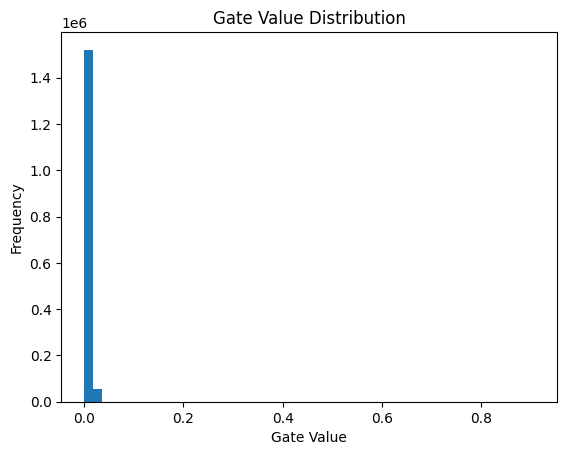

In [12]:
# PLOT GATE DISTRIBUTION

best_model_gates = results[1][3]  # choose best lambda (adjust if needed)

plt.hist(best_model_gates, bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()